In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [52]:
files = os.listdir("Datasets")
xlsx_files = [os.path.join("Datasets", f) for f in files if f.endswith('.xlsx')]
df_list = [pd.read_excel(file) for file in xlsx_files]
df = pd.concat(df_list, ignore_index=True)
df.head()

,Campaña,Despacho,Cod. trans,Pedido,Zona,Código,Identificación,Nombres,Dirección entrega,Telefono,...,Longitud,Transportador,Track,Novedad,Entregado,Anotación,Transportista,Tipo Docu,Nro visita,Estado.1
0,202407,296461,23,37076500,V02,V02004028,29121278,PAOLA ANDREA RIVILLAS AMAYA,KR 61 18 16 APTO 486 TO V CONJ CANAVERALES 3- ...,0-3165249159,...,-76.501666,TZY274,ENTREGADO,NaN,TERCERO EN DOMICILIO,NaN,daissydiaz,F,1,A TIEMPO
1,202407,296601,23,37087842,601,601004287,26396193,CERBELINA MOSQUERA MOSQUERA,KR 47A 48 39- TEL 0-3143423923,0-3143423923,...,-76.501645,CBZ922,ENTREGADO,NaN,ASESORA,NaN,daissydiaz,F,1,A TIEMPO
2,202407,296601,23,37093297,580,580011140,1112490780,MANUELA RAMIREZ SANCHEZ,CR 1H NORTE 77-10 SEGUNDO PISO- TEL 0-3154678944,0-3154678944,...,-76.487991,TZY274,ENTREGADO,NaN,ASESORA,NaN,daissydiaz,F,1,A TIEMPO
3,202407,296621,23,37098642,594,594003236,66940803,FANERY CORRLES BERMUDES,CALLETERSERA SN124- TEL 0-3016931064,0-3016931064,...,-76.687145,TZN919,ENTREGADO,NaN,ASESORA,NaN,daissydiaz,F,1,A TIEMPO
4,202407,296832,23,37105003,603,60301124,25717466,MARCIA FLOREZ LOPEZ,CL 18 A 9 A 11 PISO NO 1- TEL 0-3136142043,0-3136142043,...,-76.531023,CEN356,ENTREGADO,NaN,ASESORA,NaN,daissydiaz,F,1,A TIEMPO


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55275 entries, 0 to 55274
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Campaña            55275 non-null  int64  
 1   Despacho           55275 non-null  int64  
 2   Cod. trans         55275 non-null  int64  
 3   Pedido             55275 non-null  int64  
 4   Zona               55275 non-null  object 
 5   Código             55275 non-null  object 
 6   Identificación     55275 non-null  int64  
 7   Nombres            55275 non-null  object 
 8   Dirección entrega  55273 non-null  object 
 9   Telefono           55273 non-null  object 
 10  Barrio             55275 non-null  object 
 11  Ciudad             55275 non-null  object 
 12  Fecha pedido       55275 non-null  object 
 13  Fecha facturado    55275 non-null  object 
 14  Hora facturado     55275 non-null  object 
 15  Fecha embalado     55266 non-null  object 
 16  Hora embalado      552

In [54]:
df.drop(["Despacho", "Cod. trans", "Código", "Identificación", "Nombres", "Fecha pedido", 
         "Fecha facturado", "Hora facturado", "Fecha embalado", "Hora embalado", "Fecha despachado", "Estado", "Dias entregado",
         "Cajas", "Corte", "Placa vehiculo", "Regional", "Line pick", "Fecha masivo", "Latitud", "Longitud", "Track",
         "Novedad", "Entregado", "Anotación", "Transportista", "Tipo Docu", "Nro visita"], axis=1, inplace=True)

In [55]:
if 'Estado.1' in df.columns:
    df.rename(columns={'Estado.1':'Estado'}, inplace=True)

In [56]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50828 entries, 1 to 55274
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Campaña            50828 non-null  int64 
 1   Pedido             50828 non-null  int64 
 2   Zona               50828 non-null  object
 3   Dirección entrega  50828 non-null  object
 4   Telefono           50828 non-null  object
 5   Barrio             50828 non-null  object
 6   Ciudad             50828 non-null  object
 7   Fecha recibo LD    50828 non-null  object
 8   Fecha reparto      50828 non-null  object
 9   Fecha entrega      50828 non-null  object
 10  Transportador      50828 non-null  object
 11  Estado             50828 non-null  object
dtypes: int64(2), object(10)
memory usage: 5.0+ MB


In [57]:
# Convertir fechas
df["Fecha recibo LD"] = pd.to_datetime(df["Fecha recibo LD"])
df["Fecha reparto"] = pd.to_datetime(df["Fecha reparto"])
df["Fecha entrega"] = pd.to_datetime(df["Fecha entrega"])

In [58]:
df["horas_entrega"] = (
    df["Fecha entrega"] - df["Fecha reparto"]
).dt.total_seconds() / 3600

In [59]:
import numpy as np

df["umbral"] = np.where(
    df["Ciudad"] == "CALI (VALLE)",
    24,
    48
)

In [60]:
df["Estado"] = df["Estado"].str.upper().str.strip()

In [61]:
mask_incons = (
    ((df["horas_entrega"] > df["umbral"]) & (df["Estado"] == "A TIEMPO")) |
    ((df["horas_entrega"] <= df["umbral"]) & (df["Estado"] == "TARDE"))
)

In [62]:
print("Total inconsistentes:", mask_incons.sum())
print("Total registros:", len(df))

Total inconsistentes: 17764
Total registros: 50828


In [63]:
df[mask_incons][[
    "Ciudad", "Barrio", "horas_entrega", "umbral", "Estado"
]].head(10)

,Ciudad,Barrio,horas_entrega,umbral,Estado
7,CALI (VALLE),CIUDAD CORDOBA,29.445278,24,A TIEMPO
8,CALI (VALLE),CIUDAD CORDOBA,29.368611,24,A TIEMPO
9,SANTANDER DE QUILICHAO (CAUCA),BELLO HORIZONTE 2,13.135000,48,TARDE
14,CALI (VALLE),VALLADO,23.941389,24,TARDE
18,CALI (VALLE),CORDOBA,33.561944,24,A TIEMPO
20,CALI (VALLE),CIUDAD CORDOBA,23.985833,24,TARDE
25,YUMBO (VALLE),URIBE,29.076667,48,TARDE
27,CALI (VALLE),MARIANO RAMOS,26.811944,24,A TIEMPO
33,CALI (VALLE),VERGEL,26.554167,24,A TIEMPO
38,CALI (VALLE),LA FORTALEZA,52.230833,24,A TIEMPO


In [64]:
# Caso 1: dice A TIEMPO pero está tarde
error_tipo_1 = (df["horas_entrega"] > df["umbral"]) & (df["Estado"] == "A TIEMPO")

# Caso 2: dice TARDE pero está a tiempo
error_tipo_2 = (df["horas_entrega"] <= df["umbral"]) & (df["Estado"] == "TARDE")

print("Error tipo 1 (A TIEMPO pero tarde):", error_tipo_1.sum())
print("Error tipo 2 (TARDE pero a tiempo):", error_tipo_2.sum())

Error tipo 1 (A TIEMPO pero tarde): 12592
Error tipo 2 (TARDE pero a tiempo): 5172


In [65]:
df.groupby("Estado")["horas_entrega"].describe()

,count,mean,std,min,25%,50%,75%,max
Estado,,,,,,,,
A TIEMPO,36158.0,22.918210,19.804119,-140.911111,7.202361,18.905417,33.371667,122.614167
TARDE,14670.0,55.162655,59.502943,-141.626667,18.890069,44.001111,72.023056,1052.264444


In [66]:
porcentaje = mask_incons.mean()

print(f"Porcentaje de inconsistencias: {porcentaje:.4f} ({porcentaje*100:.2f}%)")

Porcentaje de inconsistencias: 0.3495 (34.95%)


In [67]:
df[mask_incons].groupby("Ciudad").size().sort_values(ascending=False).head(10)

Ciudad
CALI (VALLE)                      14439
JAMUNDI (VALLE)                     705
PUERTO TEJADA (CAUCA)               521
SANTANDER DE QUILICHAO (CAUCA)      496
YUMBO (VALLE)                       416
DAGUA (VALLE)                       303
POTRERITO-ROBLES-TIMBA              177
SUAREZ CAUCA                        117
MONDOMO (CAUCA)                     106
VILLARICA CAUCA                     104
dtype: int64

In [68]:
df[mask_incons].groupby("Transportador").size().sort_values(ascending=False).head(10)

Transportador
YAB258    4218
TZY274    2409
WHU392    2029
MBJ371    1842
CFG119    1107
YAB291     891
CBL490     847
CBZ922     817
CEN356     599
FJM605     558
dtype: int64

In [69]:
df_clean = df[~mask_incons]

print("Datos originales:", len(df))
print("Datos limpios:", len(df_clean))
print("Porcentaje restante:", len(df_clean)/len(df))

Datos originales: 50828
Datos limpios: 33064
Porcentaje restante: 0.6505075942393956


In [70]:
df_clean["Ciudad"].value_counts(normalize=True)

Ciudad
CALI (VALLE)                         0.747853
JAMUNDI (VALLE)                      0.059400
SANTANDER DE QUILICHAO (CAUCA)       0.046516
YUMBO (VALLE)                        0.036051
PUERTO TEJADA (CAUCA)                0.022078
DAGUA (VALLE)                        0.018691
VILLARICA CAUCA                      0.012703
SUAREZ CAUCA                         0.010525
MONDOMO (CAUCA)                      0.009376
CALOTO (CAUCA)                       0.007168
POTRERITO-ROBLES-TIMBA               0.006684
BUENOS AIRES CAUCA                   0.004174
GUACHENE (CAUCA)                     0.003478
LA CUMBRE (VALLE)                    0.003024
TORIBIO  (CAUCA)                     0.002692
VIJES (VALLE)                        0.002268
FELIDIA- VIA CALI DAGUA              0.002057
VILLA GORGONA (VALLE)                0.001089
CANDELARIA VALLE DEL CAUCA           0.000847
EL CHARCO (NARINO)                   0.000786
DAPA (VALLE)                         0.000605
LOPEZ DE MICAY CAUCA       

In [71]:
df["Ciudad"].value_counts(normalize=True)

Ciudad
CALI (VALLE)                         0.770560
JAMUNDI (VALLE)                      0.052510
SANTANDER DE QUILICHAO (CAUCA)       0.040017
YUMBO (VALLE)                        0.031636
PUERTO TEJADA (CAUCA)                0.024612
DAGUA (VALLE)                        0.018120
VILLARICA CAUCA                      0.010309
SUAREZ CAUCA                         0.009149
MONDOMO (CAUCA)                      0.008184
POTRERITO-ROBLES-TIMBA               0.007830
CALOTO (CAUCA)                       0.005745
GUACHENE (CAUCA)                     0.003777
BUENOS AIRES CAUCA                   0.003384
VIJES (VALLE)                        0.002872
LA CUMBRE (VALLE)                    0.002656
TORIBIO  (CAUCA)                     0.002538
FELIDIA- VIA CALI DAGUA              0.001672
VILLA GORGONA (VALLE)                0.001003
DAPA (VALLE)                         0.000630
EL CHARCO (NARINO)                   0.000610
CANDELARIA VALLE DEL CAUCA           0.000571
LOPEZ DE MICAY CAUCA       

In [72]:
print("=== CIUDAD ===")

ciudad_original = df["Ciudad"].value_counts()
ciudad_clean = df_clean["Ciudad"].value_counts()

comparacion_ciudad = pd.DataFrame({
    "Original": ciudad_original,
    "Clean": ciudad_clean
}).fillna(0)

print(comparacion_ciudad)

=== CIUDAD ===
                                   Original    Clean
Ciudad                                              
ANDALUCIA (VALLE)                        10      9.0
BOGOTA (CUNDINAMARCA)                     5      3.0
BUENOS AIRES CAUCA                      172    138.0
CALI (VALLE)                          39166  24727.0
CALOTO (CAUCA)                          292    237.0
CANDELARIA VALLE DEL CAUCA               29     28.0
CODAZZI (CESAR)                           5      5.0
CORINTO (CAUCA)                           5      4.0
DAGUA (VALLE)                           921    618.0
DAPA (VALLE)                             32     20.0
EL CHARCO (NARINO)                       31     26.0
EL ROSARIO (NARINO)                       8      3.0
FELIDIA- VIA CALI DAGUA                  85     68.0
GUACHENE (CAUCA)                        192    115.0
JAMUNDI (VALLE)                        2669   1964.0
LA CUMBRE (VALLE)                       135    100.0
LOPEZ DE MICAY CAUCA           

In [73]:
ciudades_perdidas = set(df["Ciudad"]) - set(df_clean["Ciudad"])
print("Ciudades eliminadas:", ciudades_perdidas)

Ciudades eliminadas: {'ZARZAL (VALLE)', 'PRADERA (VALLE)', 'MEDELLIN (ANTIOQUIA)'}


In [74]:
ciudades_perdidas = set(df["Ciudad"]) - set(df_clean["Ciudad"])

df[df["Ciudad"].isin(ciudades_perdidas)]["Ciudad"].value_counts()

Ciudad
PRADERA (VALLE)         1
ZARZAL (VALLE)          1
MEDELLIN (ANTIOQUIA)    1
Name: count, dtype: int64

In [75]:
print("\n=== BARRIO ===")

barrio_original = df["Barrio"].value_counts()
barrio_clean = df_clean["Barrio"].value_counts()

comparacion_barrio = pd.DataFrame({
    "Original": barrio_original,
    "Clean": barrio_clean
}).fillna(0)

print(comparacion_barrio.head(20))  # para no imprimir 700 barrios


=== BARRIO ===
                        Original  Clean
Barrio                                 
*EL JARDIN*                   24   19.0
1 DE MAYO                     33   18.0
12 DE OCTUBRE                 27   21.0
20 DE JULIO                   77   63.0
7 DE AGOSTO                  254  215.0
9 DE ENERO                     3    3.0
ACACIAS                       61   41.0
AGUA AZUL                     45   39.0
AGUABLANCA                     9    4.0
ALAMEDA                       78   55.0
ALAMEDA DEL RIO               33   19.0
ALAMOS NORTE                  25   19.0
ALBORADA                     185   85.0
ALCAZARES                      6    4.0
ALCAZAREZ                    126   94.0
ALFAGUARA                     26   18.0
ALFEREZ REAL                  16    4.0
ALFONSO BARBERENA             70   57.0
ALFONSO BONILLA ARAGON       374  224.0
ALFONSO CAICEDO                1    1.0


In [76]:
barrios_perdidos = set(df["Barrio"]) - set(df_clean["Barrio"])
print("Cantidad de barrios eliminados:", len(barrios_perdidos))

Cantidad de barrios eliminados: 20


In [77]:
barrios_perdidos = set(df["Barrio"]) - set(df_clean["Barrio"])

df[df["Barrio"].isin(barrios_perdidos)]["Barrio"].value_counts()

Barrio
CIUDAD DEL SUR         4
TIERRA BLANCA          3
LA CALLEJA             3
ALTOS DE LA LUISA      3
SOLARES DE COMFANDI    2
SECTOR EL PARAISO      1
LA ESPERANZA BAJA      1
VDA PUERTO DAGUA       1
VDA MUNCHIQUE          1
LA CABANA              1
PALERMO BAJO           1
CRISTALES              1
VEREDA JUAN IGNACIO    1
CANGREJO               1
BLANQUIZAL             1
GONZALO ECHEVERRY      1
OPORTO                 1
QUINTAS DE BOLIVAR     1
FLORA                  1
EL GUABAL              1
Name: count, dtype: int64

In [78]:
print("\n=== TRANSPORTADOR ===")

trans_original = df["Transportador"].value_counts()
trans_clean = df_clean["Transportador"].value_counts()

comparacion_trans = pd.DataFrame({
    "Original": trans_original,
    "Clean": trans_clean
}).fillna(0)

print(comparacion_trans)


=== TRANSPORTADOR ===
                  Original   Clean
Transportador                     
ABD123                   3     2.0
BDA446                1225   887.0
CBL490                2429  1582.0
CBZ922                1718   901.0
CEN356                1445   846.0
CFG119                2030   923.0
CXB610                  17     9.0
FJM605                2881  2323.0
GTL764                 272   203.0
JOSE FERNEY DIAZ         1     0.0
KWM751                 571   307.0
MBJ371                3354  1512.0
NCD473                 139    97.0
NME026                 116    81.0
ONG735                1897  1363.0
SEBASTIAN               14    14.0
TZN919                 743   482.0
TZY274               11317  8908.0
VCK267                 513   347.0
WHU392                4803  2774.0
WLW779                 302   215.0
WMV363                  34    29.0
WTI105                 804   522.0
YAB258               10751  6533.0
YAB291                2325  1434.0
YAB292                1124   770

In [79]:
trans_perdidos = set(df["Transportador"]) - set(df_clean["Transportador"])
print("Transportadores eliminados:", trans_perdidos)

Transportadores eliminados: {'JOSE FERNEY DIAZ'}


In [80]:
trans_perdidos = set(df["Transportador"]) - set(df_clean["Transportador"])

df[df["Transportador"].isin(trans_perdidos)]["Transportador"].value_counts()

Transportador
JOSE FERNEY DIAZ    1
Name: count, dtype: int64

In [81]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33064 entries, 1 to 55272
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Campaña            33064 non-null  int64         
 1   Pedido             33064 non-null  int64         
 2   Zona               33064 non-null  object        
 3   Dirección entrega  33064 non-null  object        
 4   Telefono           33064 non-null  object        
 5   Barrio             33064 non-null  object        
 6   Ciudad             33064 non-null  object        
 7   Fecha recibo LD    33064 non-null  datetime64[ns]
 8   Fecha reparto      33064 non-null  datetime64[ns]
 9   Fecha entrega      33064 non-null  datetime64[ns]
 10  Transportador      33064 non-null  object        
 11  Estado             33064 non-null  object        
 12  horas_entrega      33064 non-null  float64       
 13  umbral             33064 non-null  int64         
dtypes: datetime

In [82]:
Q1 = df_clean["horas_entrega"].quantile(0.25)
Q3 = df_clean["horas_entrega"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

df_clean = df_clean[df_clean["horas_entrega"] <= limite_superior].copy()

print(f"Nuevo límite superior: {limite_superior}")
print(f"Dataset final: {len(df_clean)} registros")

Nuevo límite superior: 88.74868055555555
Dataset final: 30647 registros


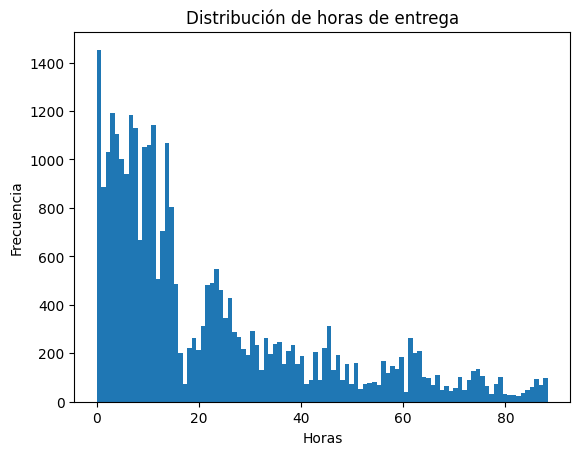

In [87]:
plt.hist(df_clean["horas_entrega"], bins=100)
plt.title("Distribución de horas de entrega")
plt.xlabel("Horas")
plt.ylabel("Frecuencia")
plt.show()

In [84]:
negativos = df_clean[df_clean["horas_entrega"] < 0]

print("Registros con horas negativas:", len(negativos))
print("Porcentaje:", len(negativos) / len(df_clean))

Registros con horas negativas: 95
Porcentaje: 0.0030998140111593306


In [85]:
negativos[[
    "Fecha recibo LD",
    "Fecha reparto",
    "Fecha entrega",
    "horas_entrega"
]].head(10)

,Fecha recibo LD,Fecha reparto,Fecha entrega,horas_entrega
4623,2024-06-28 10:30:37,2024-07-01 12:34:43,2024-07-01 10:31:00,-2.061944
4838,2024-06-28 10:23:46,2024-07-01 12:35:32,2024-07-01 09:14:08,-3.356667
4920,2024-06-28 09:14:53,2024-07-01 12:35:46,2024-07-01 10:24:16,-2.191667
5365,2024-06-28 08:37:51,2024-07-01 12:35:28,2024-07-01 09:24:52,-3.176667
5523,2024-06-28 09:03:19,2024-07-01 12:35:40,2024-07-01 09:34:01,-3.027500
5856,2024-06-28 09:05:34,2024-07-01 12:35:44,2024-07-01 10:15:14,-2.341667
6090,2024-06-28 10:05:31,2024-07-01 12:35:37,2024-07-01 09:09:26,-3.436389
10398,2024-08-28 20:46:02,2024-08-31 13:39:04,2024-08-30 14:02:23,-23.611389
18997,2024-12-21 10:05:46,2024-12-25 12:46:31,2024-12-23 13:37:42,-47.146944
19779,2024-12-21 09:14:18,2024-12-25 12:46:41,2024-12-23 13:36:59,-47.161667


In [86]:
df_clean = df_clean[df_clean["horas_entrega"] >= 0].copy()

print(f"✅ Registros negativos eliminados. Dataset ahora tiene {len(df_clean)} registros")

✅ Registros negativos eliminados. Dataset ahora tiene 30552 registros


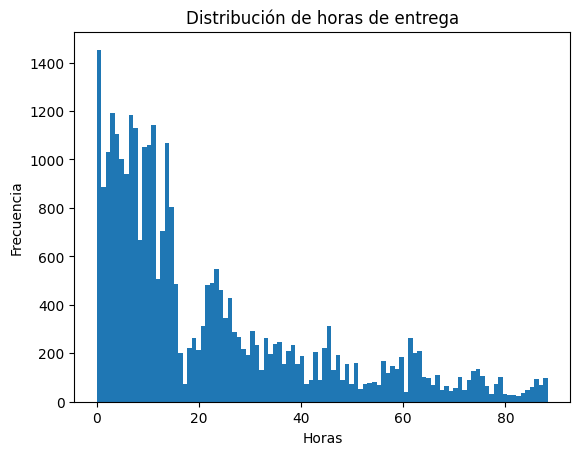

In [88]:
plt.hist(df_clean["horas_entrega"], bins=100)
plt.title("Distribución de horas de entrega")
plt.xlabel("Horas")
plt.ylabel("Frecuencia")
plt.show()

In [89]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30552 entries, 1 to 55272
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Campaña            30552 non-null  int64         
 1   Pedido             30552 non-null  int64         
 2   Zona               30552 non-null  object        
 3   Dirección entrega  30552 non-null  object        
 4   Telefono           30552 non-null  object        
 5   Barrio             30552 non-null  object        
 6   Ciudad             30552 non-null  object        
 7   Fecha recibo LD    30552 non-null  datetime64[ns]
 8   Fecha reparto      30552 non-null  datetime64[ns]
 9   Fecha entrega      30552 non-null  datetime64[ns]
 10  Transportador      30552 non-null  object        
 11  Estado             30552 non-null  object        
 12  horas_entrega      30552 non-null  float64       
 13  umbral             30552 non-null  int64         
dtypes: datetime

In [91]:
df_clean.to_csv("csv/cleaned_data.csv", index=False)